# ================================================================
#  TUTORIAL STABLE DIFFUSION — DARI NOL SAMPAI DEPLOY
#  Google Colab | Runtime → Change runtime type → GPU T4
# ================================================================
#
#  ALUR BELAJAR:
###  1. Setup & Instalasi
###  2. Apa itu Pipeline?
###  3. Generate gambar pertama
###  4. Bermain dengan parameter
###  5. Simpan gambar
###  6. Deploy dengan Gradio
# ================================================================



# ----------------------------------------------------------------
# CELL 1 | INSTALASI
# ----------------------------------------------------------------
### Kita hanya butuh 3 library utama:
###   diffusers   → berisi pipeline Stable Diffusion
###   transformers → berisi model teks (CLIP)
###   accelerate  → bantu proses di GPU lebih cepat


In [1]:
!pip install -q diffusers transformers accelerate

print("✅ Instalasi selesai!")

✅ Instalasi selesai!





# ----------------------------------------------------------------
# CELL 2 | CEK GPU
# ----------------------------------------------------------------
### Stable Diffusion BUTUH GPU agar prosesnya cepat.
### Tanpa GPU, generate 1 gambar bisa >10 menit.


In [2]:
import torch

if torch.cuda.is_available():
    print("✅ GPU aktif:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU tidak aktif!")


✅ GPU aktif: Tesla T4



# ----------------------------------------------------------------
# CELL 3 | APA ITU PIPELINE?
# ----------------------------------------------------------------

In [3]:
"""
Pipeline = "mesin all-in-one" yang mengurus semua proses:

  Kamu tulis teks
       ↓
  [1] Tokenizer   → ubah teks jadi angka
       ↓
  [2] Text Encoder (CLIP) → pahami makna teks
       ↓
  [3] U-Net       → hapus noise dari gambar acak, dibimbing teks
       ↓
  [4] VAE Decoder → ubah hasil jadi gambar nyata
       ↓
  Gambar jadi!

Tanpa pipeline, kita harus urus semua langkah itu sendiri.
Dengan pipeline, cukup 3 baris kode!
"""
print(__doc__)




Pipeline = "mesin all-in-one" yang mengurus semua proses:

  Kamu tulis teks
       ↓
  [1] Tokenizer   → ubah teks jadi angka
       ↓
  [2] Text Encoder (CLIP) → pahami makna teks
       ↓
  [3] U-Net       → hapus noise dari gambar acak, dibimbing teks
       ↓
  [4] VAE Decoder → ubah hasil jadi gambar nyata
       ↓
  Gambar jadi!

Tanpa pipeline, kita harus urus semua langkah itu sendiri.
Dengan pipeline, cukup 3 baris kode!



# ----------------------------------------------------------------
# CELL 4 | LOAD PIPELINE
# ----------------------------------------------------------------
### from_pretrained() akan mengunduh model dari HuggingFace Hub
### otomatis tersimpan di cache, jadi download hanya sekali.


In [4]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",  # nama model di HuggingFace
    torch_dtype=torch.float16           # float16 = hemat VRAM
)

# Pindahkan model ke GPU
pipe = pipe.to("cuda")

print("✅ Pipeline siap digunakan!")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Pipeline siap digunakan!




# ----------------------------------------------------------------
# CELL 5 | GENERATE GAMBAR PERTAMA
# ----------------------------------------------------------------
### Ini inti dari semuanya.
### Kita cukup tulis deskripsi → pipeline mengurus sisanya.


  0%|          | 0/50 [00:00<?, ?it/s]

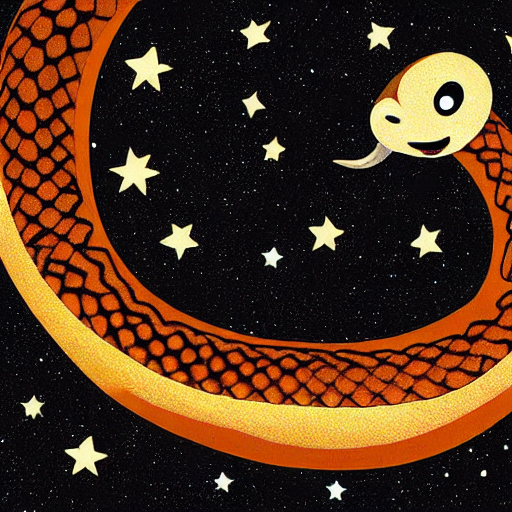

In [7]:
prompt = "a snake sitting on the moon, stars in background, digital art"

image = pipe(prompt).images[0]

image   # tampilkan gambar di Colab


# ----------------------------------------------------------------
# CELL 6 | MEMAHAMI PARAMETER PENTING
# ----------------------------------------------------------------



Ada 3 parameter yang paling sering dipakai:

  negative_prompt → apa yang TIDAK ingin muncul di gambar

  guidance_scale  → seberapa patuh gambar ke prompt

                    nilai kecil (1-5) = lebih bebas/artistik
                    nilai besar (8-15) = lebih patuh ke teks
  
  num_inference_steps → berapa langkah proses denoising
  
                        lebih banyak = lebih detail, lebih lambat
                        20-30 sudah cukup baik



  0%|          | 0/25 [00:00<?, ?it/s]

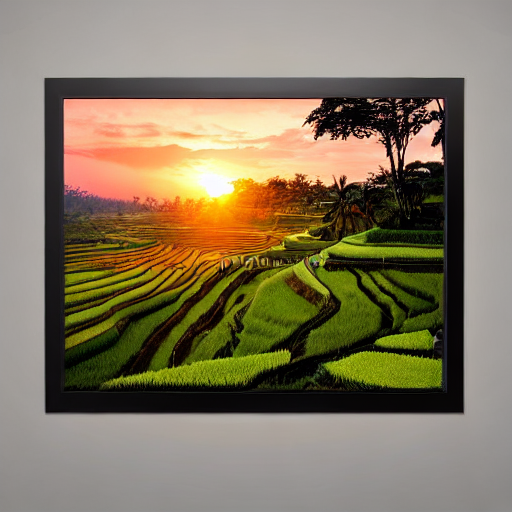

In [10]:
image = pipe(
    prompt          = "a beautiful sunset over Bali rice fields, "
                      "photorealistic, golden hour",
    negative_prompt = "light, pretty, hight quality",
    guidance_scale  = 5.5,   # default yang bagus untuk kebanyakan prompt
    num_inference_steps = 25 # cukup untuk kualitas baik
).images[0]

image


# ----------------------------------------------------------------
# CELL 7 | SEED — BUAT HASIL BISA DIULANG
# ----------------------------------------------------------------
### Tanpa seed → setiap generate hasilnya berbeda (random)
### Dengan seed → hasilnya SAMA setiap kali dijalankan
### Berguna untuk eksperimen dan debugging.
### Coba jalankan cell ini beberapa kali → hasilnya selalu sama!


  0%|          | 0/25 [00:00<?, ?it/s]

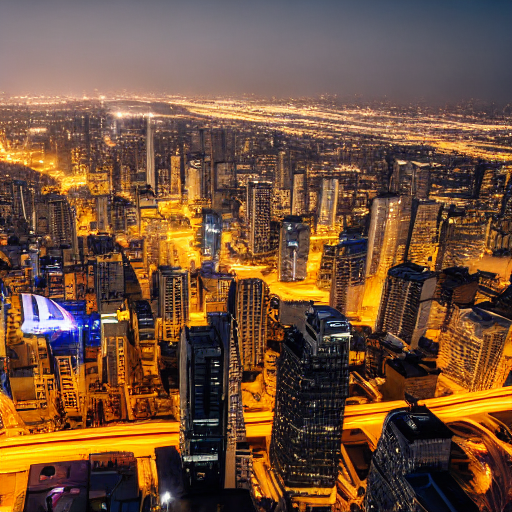

In [ ]:
generator = torch.Generator("cuda").manual_seed(42)

image = pipe(
    prompt              = "a airplane flying over city skyline, "
                          "cinematic lighting, detailed",
    negative_prompt     = "blurry, ugly",
    guidance_scale      = 7.5,
    num_inference_steps = 25,
    generator           = generator   # ← tambahkan ini
).images[0]

image


# ----------------------------------------------------------------
# CELL 8 | UKURAN GAMBAR
# ----------------------------------------------------------------
### Default ukuran SD v1.5 adalah 512x512.
### Kita bisa ubah, tapi harus KELIPATAN 64.
### Makin besar → makin lama prosesnya.

  0%|          | 0/25 [00:00<?, ?it/s]

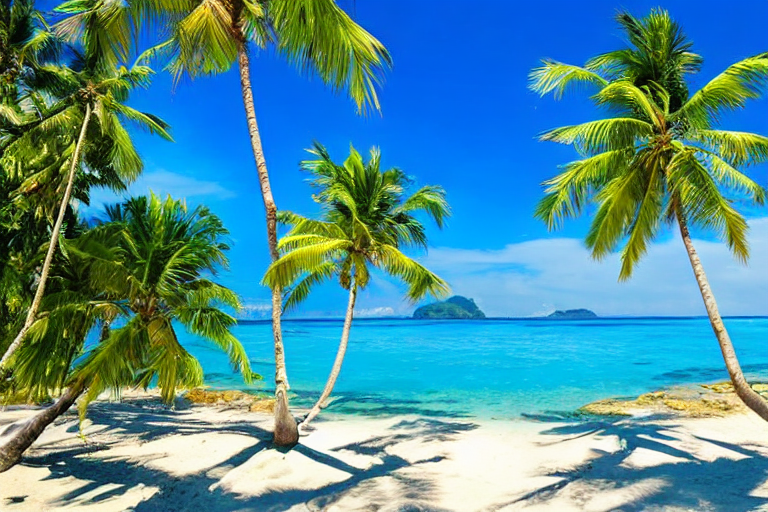

In [ ]:
image_landscape = pipe(
    prompt              = "beautiful Indonesian beach, clear water, "
                          "palm trees, sunny day",
    negative_prompt     = "blurry, ugly, people",
    guidance_scale      = 7.5,
    num_inference_steps = 25,
    width               = 768,   # lebih lebar
    height              = 512,
    generator           = torch.Generator("cuda").manual_seed(10)
).images[0]

image_landscape


In [ ]:

# ----------------------------------------------------------------
# CELL 9 | SIMPAN GAMBAR
# ----------------------------------------------------------------
### Gambar hasil generate adalah objek PIL Image
### yang bisa langsung disimpan.


In [ ]:

prompt = "Indonesian batik pattern, traditional art, colorful, detailed"

image = pipe(
    prompt              = prompt,
    negative_prompt     = "blurry, ugly",
    guidance_scale      = 7.5,
    num_inference_steps = 25,
    generator           = torch.Generator("cuda").manual_seed(99)
).images[0]

# Simpan ke file
image.save("hasil_saya.png")
print("✅ Gambar tersimpan: hasil_saya.png")


  0%|          | 0/25 [00:00<?, ?it/s]

✅ Gambar tersimpan: hasil_saya.png


In [ ]:
# Download ke komputer (khusus Colab)
from google.colab import files
files.download("hasil_saya.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ----------------------------------------------------------------
# CELL 10 | GENERATE BANYAK GAMBAR SEKALIGUS
# ----------------------------------------------------------------
### Kita bisa generate beberapa gambar dari satu prompt
### dan pilih yang terbaik.


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

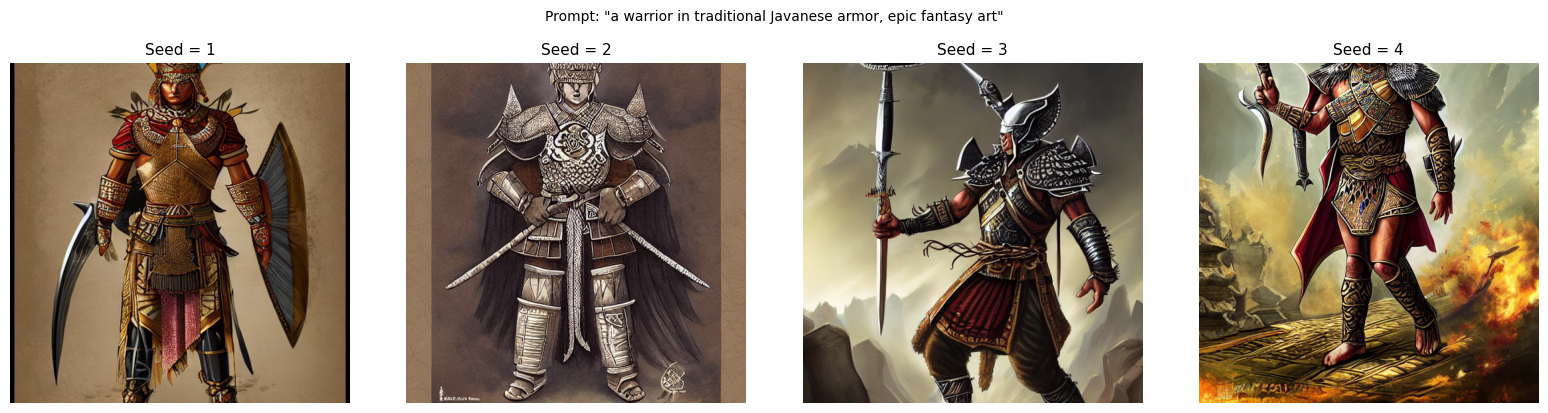

Pilih yang terbaik dan simpan!


In [ ]:
import matplotlib.pyplot as plt

prompt = "a warrior in traditional Javanese armor, epic fantasy art"

# Generate 4 gambar sekaligus dengan seed berbeda
gambar = []
for seed in [1, 2, 3, 4]:
    img = pipe(
        prompt              = prompt,
        negative_prompt     = "blurry, ugly, low quality",
        guidance_scale      = 7.5,
        num_inference_steps = 20,
        generator           = torch.Generator("cuda").manual_seed(seed)
    ).images[0]
    gambar.append(img)

# Tampilkan semua dalam grid
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, seed in zip(axes, gambar, [1, 2, 3, 4]):
    ax.imshow(img)
    ax.set_title(f"Seed = {seed}", fontsize=11)
    ax.axis("off")
plt.suptitle(f'Prompt: "{prompt}"', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

print("Pilih yang terbaik dan simpan!")
gambar[0].save("pilihan_terbaik.png")   # simpan gambar seed=1




# ================================================================
# CELL 11 | DEPLOY DENGAN GRADIO
# ================================================================
### Gradio membuat UI web interaktif dari kode Python kita.
### Dengan .launch(share=True) → dapat link publik 72 jam gratis.


In [ ]:

!pip install -q gradio

import gradio as gr

# Fungsi yang akan dipanggil setiap user klik "Generate"
def generate_image(prompt, negative_prompt, guidance_scale, steps, seed):

    # Validasi input
    if not prompt.strip():
        return None

    generator = torch.Generator("cuda").manual_seed(int(seed))

    image = pipe(
        prompt              = prompt,
        negative_prompt     = negative_prompt,
        guidance_scale      = guidance_scale,
        num_inference_steps = int(steps),
        generator           = generator
    ).images[0]

    return image


# Buat tampilan UI
with gr.Blocks(title="Stable Diffusion Demo") as demo:

    gr.Markdown("# 🎨 Stable Diffusion Text-to-Image")
    gr.Markdown("Ketik deskripsi gambar → klik Generate!")

    with gr.Row():

        # Kolom kiri: input
        with gr.Column():
            prompt_box = gr.Textbox(
                label       = "Prompt (deskripsi gambar)",
                placeholder = "contoh: a cat on the moon, digital art",
                lines       = 3
            )
            neg_box = gr.Textbox(
                label = "Negative Prompt (yang TIDAK diinginkan)",
                value = "blurry, ugly, low quality",
                lines = 2
            )
            cfg_slider   = gr.Slider(1, 15, value=7.5, step=0.5,
                                     label="Guidance Scale")
            step_slider  = gr.Slider(10, 50, value=25, step=5,
                                     label="Steps")
            seed_number  = gr.Number(value=42, label="Seed",
                                     precision=0)
            btn = gr.Button("🚀 Generate", variant="primary")

        # Kolom kanan: output
        with gr.Column():
            output_image = gr.Image(label="Hasil Gambar")

    # Hubungkan tombol ke fungsi
    btn.click(
        fn      = generate_image,
        inputs  = [prompt_box, neg_box, cfg_slider, step_slider, seed_number],
        outputs = output_image
    )

    # Contoh prompt siap pakai
    gr.Examples(
        examples = [
            ["beautiful Bali rice terraces at sunrise, photorealistic",
             "blurry, ugly", 7.5, 25, 42],
            ["Indonesian street food vendor at night, warm bokeh, cinematic",
             "blurry, ugly", 8.0, 25, 123],
            ["Komodo dragon portrait, wildlife photography, sharp",
             "blurry, ugly", 7.5, 25, 77],
        ],
        inputs = [prompt_box, neg_box, cfg_slider, step_slider, seed_number]
    )


# Launch → akan muncul link publik
demo.launch(share=True)



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2208f9e6cacea6ac5a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Deployment ke hugging space

In [ ]:
import os
from huggingface_hub import HfApi

HF_TOKEN    = ""
HF_USERNAME = "yazidsupriadi"
NAMA_SPACE  = "stable-diffusion-demo"
REPO_ID     = f"{HF_USERNAME}/{NAMA_SPACE}"

os.makedirs("my_space", exist_ok=True)

# ── requirements.txt ──────────────────────────
with open("my_space/requirements.txt", "w") as f:
    f.write(
        "diffusers>=0.30.0\n"
        "transformers>=4.45.0\n"
        "accelerate>=0.34.0\n"
        "torch\n"
        "Pillow\n"
    )
print("✅ requirements.txt")

# ── app.py ────────────────────────────────────
with open("my_space/app.py", "w") as f:
    f.write('''
import gradio as gr
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.float16 if device == "cuda" else torch.float32

print(f"Loading model on {device}...")
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
).to(device)
print("Model ready!")

def generate_image(prompt, negative_prompt, guidance_scale, steps, seed):
    if not prompt.strip():
        return None
    generator = torch.Generator(device).manual_seed(int(seed))
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance_scale,
        num_inference_steps=int(steps),
        generator=generator
    ).images[0]
    return image

with gr.Blocks(title="Stable Diffusion Demo") as demo:
    gr.Markdown("# 🎨 Stable Diffusion Text-to-Image")
    gr.Markdown("Ketik deskripsi gambar lalu klik Generate!")

    with gr.Row():
        with gr.Column():
            prompt_box  = gr.Textbox(label="Prompt", lines=3,
                                     placeholder="a cat on the moon, digital art")
            neg_box     = gr.Textbox(label="Negative Prompt",
                                     value="blurry, ugly, low quality")
            cfg_slider  = gr.Slider(1, 15, 7.5, step=0.5, label="Guidance Scale")
            step_slider = gr.Slider(10, 50, 25, step=5,   label="Steps")
            seed_box    = gr.Number(42, label="Seed", precision=0)
            btn         = gr.Button("🚀 Generate", variant="primary")
        with gr.Column():
            out = gr.Image(label="Hasil")

    btn.click(
        generate_image,
        [prompt_box, neg_box, cfg_slider, step_slider, seed_box],
        out
    )
    gr.Examples(
        [["beautiful Bali rice terraces at sunrise, photorealistic",
          "blurry, ugly", 7.5, 25, 42]],
        inputs=[prompt_box, neg_box, cfg_slider, step_slider, seed_box]
    )

demo.launch()
''')
print("✅ app.py")


with open("my_space/README.md", "w") as f:
    f.write(f"""---
title: Stable Diffusion Demo
emoji: 🎨
colorFrom: purple
colorTo: pink
sdk: gradio
sdk_version: "5.29.0"
app_file: app.py
hardware: a10g-small
pinned: false
---

# 🎨 Stable Diffusion Text-to-Image Demo
Generate gambar dari teks menggunakan Stable Diffusion v1.5.
""")
print("✅ README.md  (sdk_version → 5.29.0)")

# ── Upload ────────────────────────────────────
api = HfApi(token=HF_TOKEN)
api.upload_folder(
    folder_path    = "my_space",
    repo_id        = REPO_ID,
    repo_type      = "space",
    token          = HF_TOKEN,
    commit_message = "fix: gradio 5.x for Python 3.13 audioop compatibility"
)

print(f"""
✅ Upload selesai!

🌐 https://huggingface.co/spaces/{REPO_ID}
📋 https://huggingface.co/spaces/{REPO_ID}/logs

⏳ Tunggu ±5 menit hingga status Running
""")

✅ requirements.txt
✅ app.py
✅ README.md  (sdk_version → 5.29.0)

✅ Upload selesai!

🌐 https://huggingface.co/spaces/yazidsupriadi/stable-diffusion-demo
📋 https://huggingface.co/spaces/yazidsupriadi/stable-diffusion-demo/logs

⏳ Tunggu ±5 menit hingga status Running

